In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [2]:
# Loading dataset
df = pd.read_csv('../data/raw/Sample - Superstore.csv', encoding = 'windows-1252')
print("Data loaded successfully!")
print('shape :', df.shape)

Data loaded successfully!
shape : (9994, 21)


In [3]:
print("First 5 rows of the dataset:")
print(df.head())

print('\nLast 5 rows of the dataset:')
print(df.tail())    

print("\nDATASET SHAPE:")
print(f'Rows:{df.shape[0]}')  # Number of rows
print(f'Columns:{df.shape[1]}')  # Number of columns

First 5 rows of the dataset:
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Cat

In [4]:
print("COLUMN NAMES AND DATA TYPES:")
print(df.dtypes)

print("\nCOLUMN NAMES LIST:")
print(df.columns.tolist())

COLUMN NAMES AND DATA TYPES:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

COLUMN NAMES LIST:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [5]:
# Handling missing values
print("MISSING VALUES PER COLUMN:")
missing = df.isnull().sum()
print(missing > 0)

print(f'Total Missing Values:{df.isnull().sum().sum()}')
print(f'Total cells in dataset: {df.shape[0] * df.shape[1]}')

MISSING VALUES PER COLUMN:
Row ID           False
Order ID         False
Order Date       False
Ship Date        False
Ship Mode        False
Customer ID      False
Customer Name    False
Segment          False
Country          False
City             False
State            False
Postal Code      False
Region           False
Product ID       False
Category         False
Sub-Category     False
Product Name     False
Sales            False
Quantity         False
Discount         False
Profit           False
dtype: bool


Total Missing Values:0
Total cells in dataset: 209874


In [6]:
# Statistical description of dataset
print("BASIC STATISTICS FOR NUMERICAL COLUMNS:")
display(df.describe().round(2))

BASIC STATISTICS FOR NUMERICAL COLUMNS:


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00
mean,4997.50,55190.38,229.86,3.79,0.16,28.66
std,2885.16,32063.69,623.25,2.23,0.21,234.26
min,1.00,1040.00,0.44,1.00,0.00,-6599.98
25%,2499.25,23223.00,17.28,2.00,0.00,1.73
50%,4997.50,56430.50,54.49,3.00,0.20,8.67
75%,7495.75,90008.00,209.94,5.00,0.20,29.36
max,9994.00,99301.00,22638.48,14.00,0.80,8399.98


In [7]:
# Converting date columns to proper date format and extracting useful features
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month Name'] = df['Order Date'].dt.strftime('%B')
df['Order Day'] = df['Order Date'].dt.day_name()
df['Ship Duration'] = (df['Ship Date'] - df['Order Date']).dt.days

print("Date columns fixed!")
print("\nNew columns added:")

display(df[['Order Date', 'Order Year', 'Order Month', 'Order Month Name', 'Ship Duration']].head())
print(df.dtypes)



Date columns fixed!

New columns added:


,Order Date,Order Year,Order Month,Order Month Name,Ship Duration
0,2016-11-08,2016,11,November,3
1,2016-11-08,2016,11,November,3
2,2016-06-12,2016,6,June,4
3,2015-10-11,2015,10,October,7
4,2015-10-11,2015,10,October,7


Row ID                       int64
Order ID                    object
Order Date          datetime64[ns]
Ship Date           datetime64[ns]
Ship Mode                   object
Customer ID                 object
Customer Name               object
Segment                     object
Country                     object
City                        object
State                       object
Postal Code                  int64
Region                      object
Product ID                  object
Category                    object
Sub-Category                object
Product Name                object
Sales                      float64
Quantity                     int64
Discount                   float64
Profit                     float64
Order Year                   int32
Order Month                  int32
Order Month Name            object
Order Day                   object
Ship Duration                int64
dtype: object


In [8]:
# Handling duplicates
print(f'No. of Duplicate Rows: {df.duplicated().sum()} ')

df= df.drop_duplicates()
print(f"Dataset shape after removing duplicates: {df.shape}")

No. of Duplicate Rows: 0 
Dataset shape after removing duplicates: (9994, 26)


In [9]:
# Saving cleaned dataset
df.to_csv('../data/processed/Sample Superstore Cleaned.csv', index = False)
print("✅ Cleaned data saved to data/processed/superstore_cleaned.csv")
print(f"Final dataset shape: {df.shape}")

✅ Cleaned data saved to data/processed/superstore_cleaned.csv
Final dataset shape: (9994, 26)


In [10]:
# Sales and Profit by category
category_analysis = df.groupby('Category')[['Sales','Profit']].sum().round(2)

category_analysis['Profit Margin %'] = (category_analysis['Profit'] /  category_analysis['Sales'] * 100).round(2)
print("SALES AND PROFIT BY CATEGORY:")
display(category_analysis.sort_values("Sales", ascending = False))

SALES AND PROFIT BY CATEGORY:


,Sales,Profit,Profit Margin %
Category,,,
Technology,836154.03,145454.95,17.40
Furniture,741999.80,18451.27,2.49
Office Supplies,719047.03,122490.80,17.04


In [11]:
# Sales and Profit by region
region_analysis = df.groupby('Region')[['Sales','Profit']].sum().round(2)
region_analysis = region_analysis.sort_values('Sales', ascending = False)
print("SALES AND PROFIT BY REGION:")
display(region_analysis)

SALES AND PROFIT BY REGION:


,Sales,Profit
Region,,
West,725457.82,108418.45
East,678781.24,91522.78
Central,501239.89,39706.36
South,391721.90,46749.43


In [12]:
# Monthly sales trend
monthly_sales = df.groupby(['Order Year', 'Order Month'])[['Sales']].sum().reset_index()
monthly_sales = monthly_sales.sort_values(['Order Year', 'Order Month'])
print("MONTHLY SALES (first 12 rows):")
display(monthly_sales.head(12))

MONTHLY SALES (first 12 rows):


,Order Year,Order Month,Sales
0,2014,1,14236.8950
1,2014,2,4519.8920
2,2014,3,55691.0090
3,2014,4,28295.3450
4,2014,5,23648.2870
5,2014,6,34595.1276
6,2014,7,33946.3930
7,2014,8,27909.4685
8,2014,9,81777.3508
9,2014,10,31453.3930


In [13]:
# Top profitable products
top_products = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10).round(2)
display(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.93
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.04
Hewlett Packard LaserJet 3310 Copier                                            6983.88
Canon PC1060 Personal Laser Copier                                              4570.93
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.98
Ativa V4110MDD Micro-Cut Shredder                                               3772.95
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.97
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.28
Ibico EPK-21 Electric Binding System                                            3345.28
Zebra ZM400 Thermal Label Printer                                               3343.54
Name: Profit, dtype: float64

In [14]:
import warnings 
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

sns.set_theme(style = 'white')
sns.set_palette('Set2')

print("Chart styling configured")

Chart styling configured


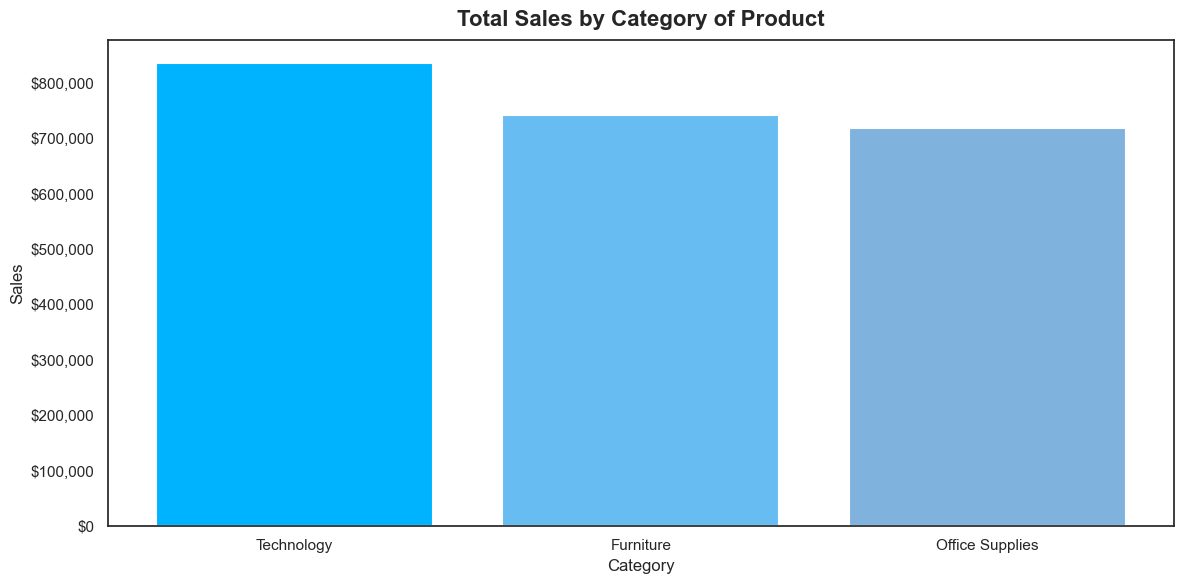

In [15]:
# Sales by category(bar chart)

fig, ax = plt.subplots()
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending = False)
bars = ax.bar(category_sales.index,
              category_sales.values,
              color=["#00B3FF", "#67BCF1", "#7fb3de"],
              edgecolor='white',
              linewidth=1.5)
ax.set_title('Total Sales by Category of Product',fontsize=16, fontweight='bold', pad=10)
ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Sales', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('../outputs/01_sales_by_category.png', dpi=300, bbox_inches='tight')
plt.show()

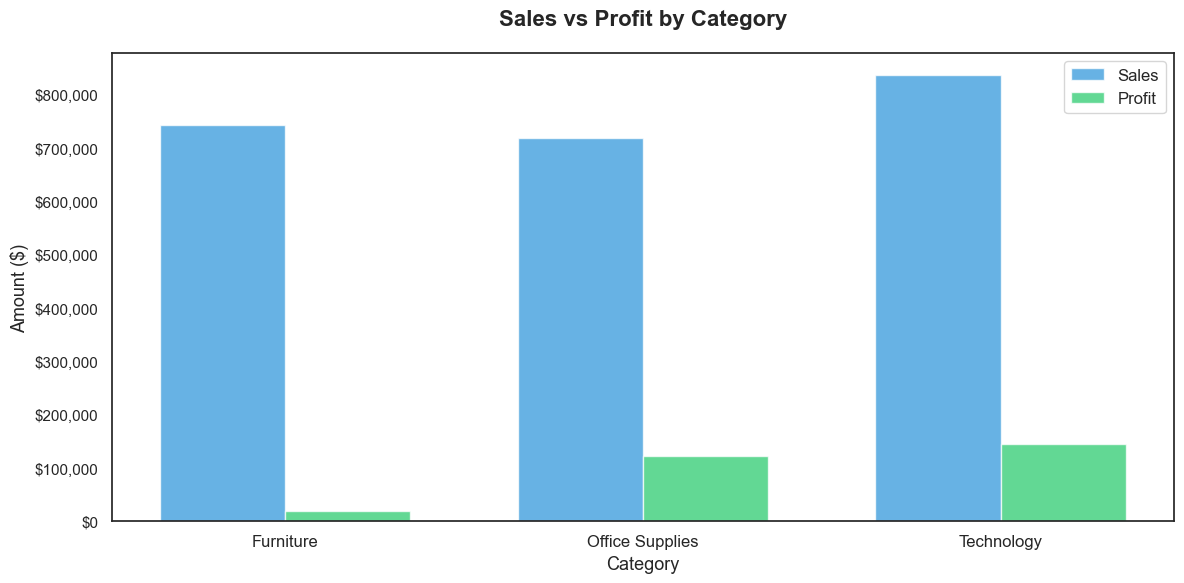

In [16]:
# Sales vs Profit by Category
fig, ax = plt.subplots()

category_data = df.groupby('Category')[['Sales', 'Profit']].sum()

x = range(len(category_data.index))
width = 0.35

bars1 = ax.bar( [i - width/2 for i in x],
               category_data['Sales'],
               width, label='Sales', 
               color='#3498db', alpha=0.75)

bars2 = ax.bar([i + width/2 for i in x],
               category_data['Profit'],
               width, label='Profit', 
               color='#2ecc71', alpha=0.75)

ax.set_title('Sales vs Profit by Category', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Category', fontsize=13)
ax.set_ylabel('Amount ($)', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(category_data.index, fontsize=12)
ax.legend(fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('../outputs/02_sales_vs_profit_category.png', dpi=300, bbox_inches='tight')
plt.show()


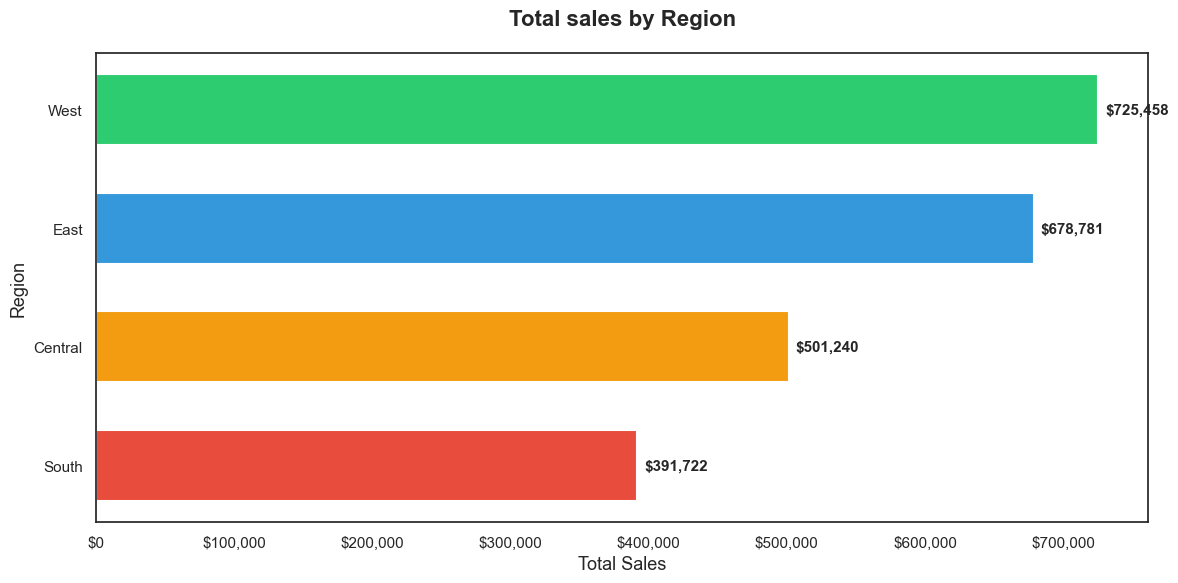

In [17]:
# Sales by Region
fig, ax = plt.subplots()
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending = True)
colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']
bars = ax.barh(region_sales.index, 
               region_sales.values, 
               color=colors,
               edgecolor='white',
               linewidth=1.5,
               height=0.6)
for bar, value in zip(bars, region_sales.values):
    ax.text(value + 5000, 
            bar.get_y() + bar.get_height()/2,
            f'${value:,.0f}',
            va='center',
            fontweight='bold',
            fontsize=11)
ax.set_title('Total sales by Region', fontsize = 16, fontweight = 'bold', pad = 20)
ax.set_xlabel('Total Sales', fontsize = 13)
ax.set_ylabel('Region', fontsize = 13)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('../outputs/03_sales_by_region.png', dpi = 300, bbox_inches = 'tight')
plt.show()

11


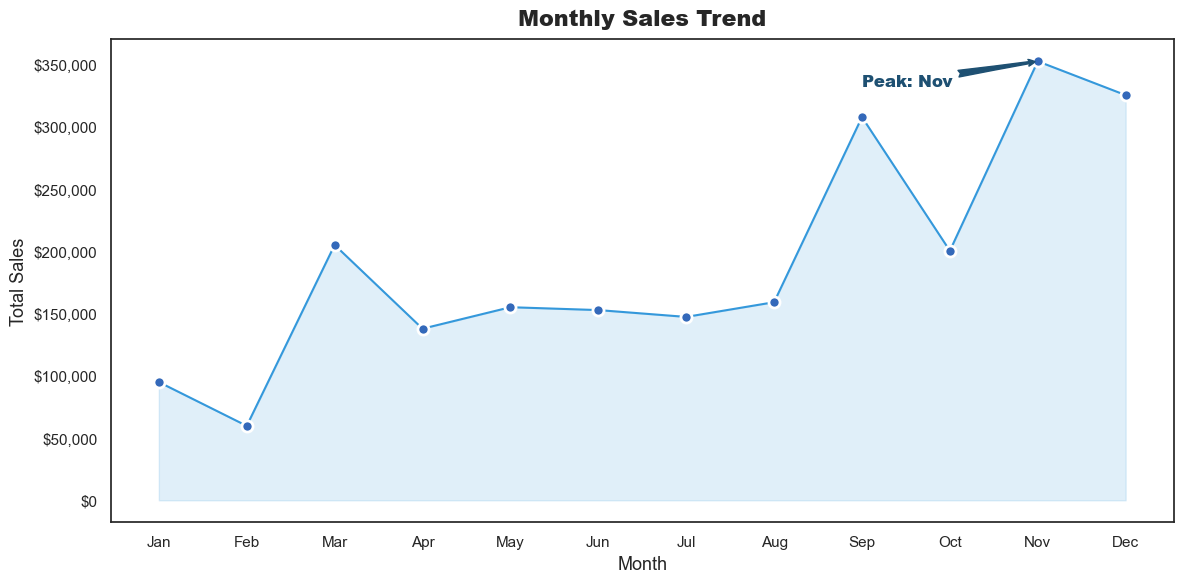

In [18]:
# Monthly sales trend
fig, ax = plt.subplots()
monthly_sales = df.groupby('Order Month')['Sales'].sum()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

ax.plot(month_names, 
        monthly_sales.values,
        color='#3498db',
        marker='o',markersize=8,
        markerfacecolor="#3469ba",
        markeredgecolor='white',
        markeredgewidth=2)
ax.fill_between(month_names, monthly_sales.values,alpha = 0.15,color='#3498db')

peak_month = monthly_sales.idxmax()
print(peak_month)

ax.annotate(f'Peak: {month_names[peak_month-1]}',
            xy=(peak_month-1, monthly_sales.max()),
            xytext=(peak_month-3, monthly_sales.max() - 20000),
            arrowprops= dict(arrowstyle='fancy', color="#1e5072"),
            fontsize=12, color='#1e5072', fontweight='heavy')

ax.set_title('Monthly Sales Trend', fontfamily='arial', fontsize=16, fontweight='heavy', pad=10)
ax.set_xlabel('Month', fontsize=13)
ax.set_ylabel('Total Sales', fontsize=13)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p : f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('../outputs/04_monthly_sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()



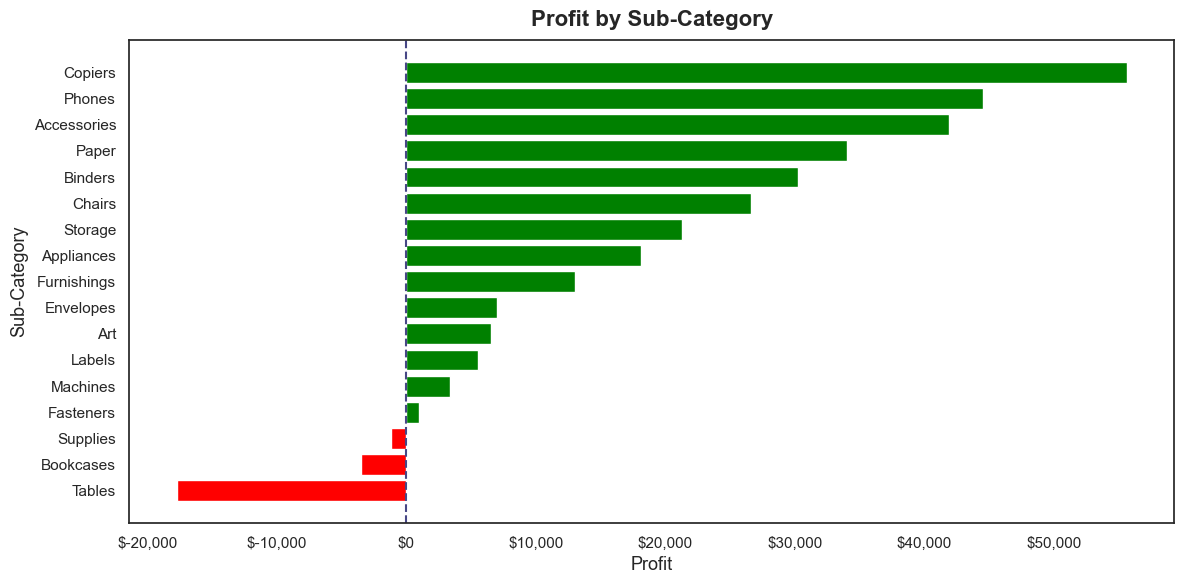

In [19]:
# Profit by Sub-Category

fig, ax = plt.subplots()

sub_category_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending = True)

sub_category_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending = True)
colors = ['red' if x<0 else 'green' for x in sub_category_profit.values]
bars = ax.barh(sub_category_profit.index, sub_category_profit.values, color = colors, edgecolor = 'white')

ax.axvline(x=0, color="#474786", linewidth=1.5, linestyle='--')
ax.set_title('Profit by Sub-Category', fontsize = 16, fontweight = 'bold', pad = 10)
ax.set_xlabel('Profit', fontsize = 13)
ax.set_ylabel('Sub-Category', fontsize = 13)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('../outputs/05_Profit_by_Sub-Category.png', dpi = 300, bbox_inches = 'tight')
plt.show()

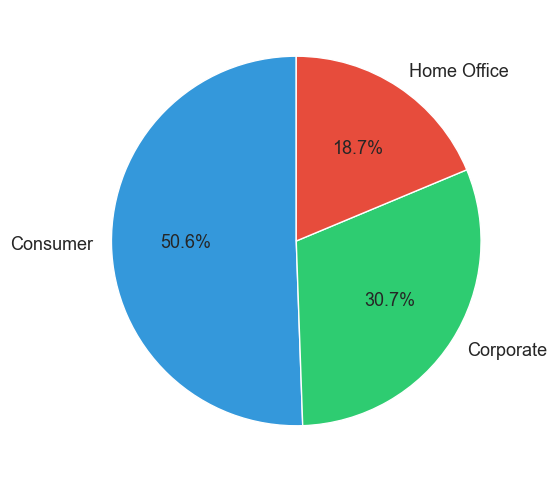

In [20]:
# Sales by Customer Segment

fig,ax = plt.subplots()

segment_sales = df.groupby('Segment')['Sales'].sum()
colors = ['#3498db', '#2ecc71', '#e74c3c']
explode = (0.05, 0.05, 0.5)

wedges, texts, autotexts = ax.pie(
    segment_sales.values,
    labels=segment_sales.index,
    autopct='%1.1f%%',
    colors=colors,
    #  explode = explode,
    startangle=90,
    textprops={'fontsize': 13}
)